<a href="https://colab.research.google.com/github/Aswinij28/Machine-Learning-and-Data-visualisation/blob/main/Extracurricular_Activity_Tracker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

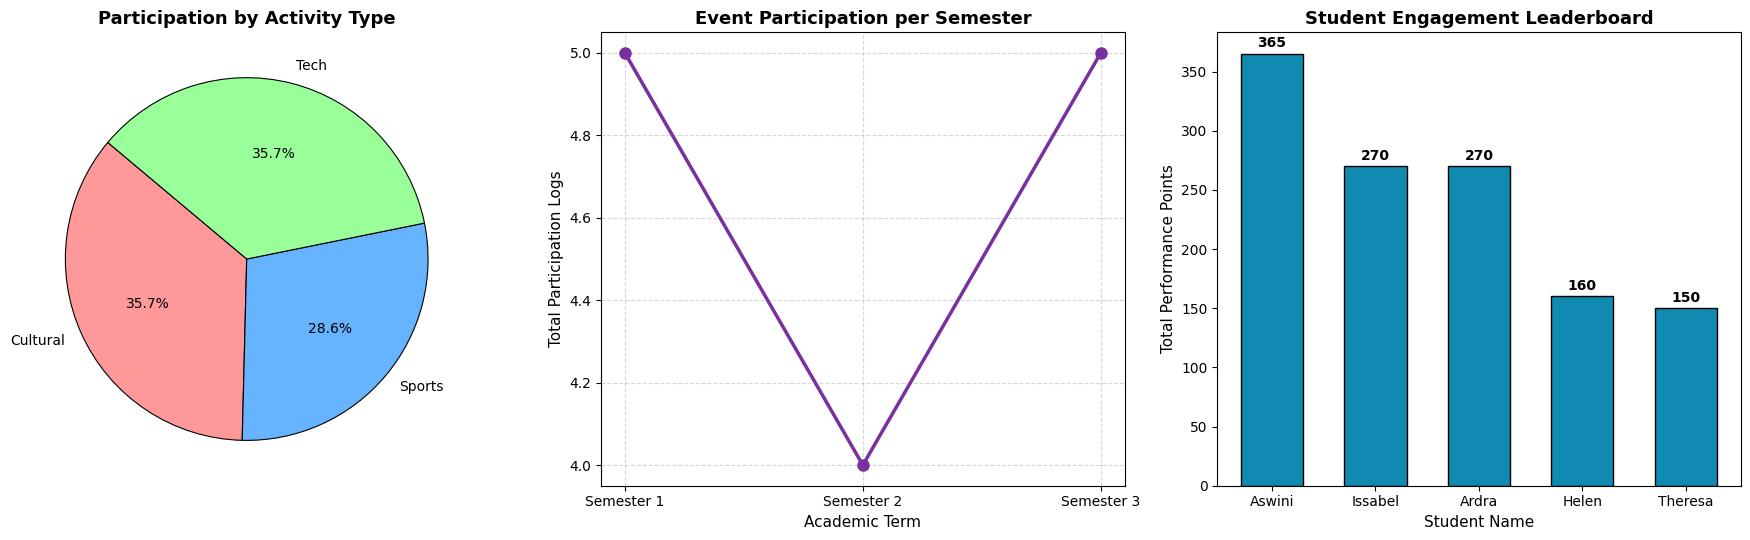

In [1]:
from abc import ABC, abstractmethod
import matplotlib.pyplot as plt

class Activity(ABC):
    """Abstract Base Class representing a general student activity."""
    def __init__(self, name):
        self.name = name

    @abstractmethod
    def get_type(self):
        """Abstract method to return the type/category of the activity."""
        pass

class CulturalActivity(Activity):
    """Specific activity class for Cultural events."""
    def get_type(self):
        return "Cultural"

class SportsActivity(Activity):
    """Specific activity class for Sports events."""
    def get_type(self):
        return "Sports"

class TechActivity(Activity):
    """Specific activity class for Technical events."""
    def get_type(self):
        return "Tech"

class Club:
    """Class representing a Student Club/Society."""
    def __init__(self, name, description=""):
        self.name = name
        self.description = description
        self.activities = []

    def add_activity(self, activity):
        self.activities.append(activity)

class Student:
    """Class representing an individual Student."""
    def __init__(self, student_id, name, department=""):
        self.student_id = student_id
        self.name = name
        self.department = department

class EventParticipation:
    """Class to link a Student to an Activity for a specific semester."""
    def __init__(self, student, activity, semester, performance_score=10):
        self.student = student
        self.activity = activity
        self.semester = semester  # e.g., "Semester 1", "Semester 2"
        self.performance_score = performance_score  # Score for the leaderboard

# Instantiate Students
student_list = [
    Student("S01", "Aswini", "CSE"),
    Student("S02", "Issabel", "ECE"),
    Student("S03", "Ardra", "EEE"),
    Student("S04", "Helen", "CSE"),
    Student("S05", "Theresa", "ME")
]

activities = [
    CulturalActivity("Dance Competition"),
    CulturalActivity("Music Fest"),
    SportsActivity("Football Tournament"),
    SportsActivity("Badminton Championship"),
    TechActivity("Hackathon"),
    TechActivity("Coding Contest")
]

participations = [
    # Semester 1
    EventParticipation(student_list[0], activities[4], "Semester 1", 95),
    EventParticipation(student_list[0], activities[1], "Semester 1", 80),
    EventParticipation(student_list[1], activities[0], "Semester 1", 85),
    EventParticipation(student_list[2], activities[2], "Semester 1", 90),
    EventParticipation(student_list[3], activities[4], "Semester 1", 75),

    # Semester 2
    EventParticipation(student_list[0], activities[5], "Semester 2", 90),
    EventParticipation(student_list[1], activities[1], "Semester 2", 95),
    EventParticipation(student_list[2], activities[3], "Semester 2", 85),
    EventParticipation(student_list[4], activities[2], "Semester 2", 80),

    # Semester 3
    EventParticipation(student_list[0], activities[4], "Semester 3", 100),
    EventParticipation(student_list[1], activities[0], "Semester 3", 90),
    EventParticipation(student_list[2], activities[5], "Semester 3", 95),
    EventParticipation(student_list[3], activities[3], "Semester 3", 85),
    EventParticipation(student_list[4], activities[1], "Semester 3", 70)
]

type_counts = {"Cultural": 0, "Sports": 0, "Tech": 0}
for p in participations:
    type_counts[p.activity.get_type()] += 1

semesters = sorted(list(set(p.semester for p in participations)))
sem_counts = {sem: 0 for sem in semesters}
for p in participations:
    sem_counts[p.semester] += 1

student_scores = {}
for p in participations:
    student_scores[p.student.name] = student_scores.get(p.student.name, 0) + p.performance_score

sorted_leaderboard = sorted(student_scores.items(), key=lambda x: x[1], reverse=True)

fig, axs = plt.subplots(1, 3, figsize=(18, 5.5))

# --- Plot 1: Pie Chart (Participation Share by Activity Type) ---
axs[0].pie(
    type_counts.values(),
    labels=type_counts.keys(),
    autopct='%1.1f%%',
    startangle=140,
    colors=['#ff9999', '#66b3ff', '#99ff99'],
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.8}
)
axs[0].set_title("Participation by Activity Type", fontsize=13, fontweight='bold')

# --- Plot 2: Time-Series / Line Plot (Engagement Trends Across Semesters) ---
axs[1].plot(
    list(sem_counts.keys()),
    list(sem_counts.values()),
    marker='o',
    color='#7a2f9e',
    linestyle='-',
    linewidth=2.5,
    markersize=8
)
axs[1].set_title("Event Participation per Semester", fontsize=13, fontweight='bold')
axs[1].set_xlabel("Academic Term", fontsize=11)
axs[1].set_ylabel("Total Participation Logs", fontsize=11)
axs[1].grid(True, linestyle='--', alpha=0.5)

# --- Plot 3: Bar Chart (Engagement Leaderboard in Sorted Order) ---
names = [entry[0] for entry in sorted_leaderboard]
scores = [entry[1] for entry in sorted_leaderboard]

axs[2].bar(names, scores, color='#118ab2', edgecolor='black', width=0.6)
axs[2].set_title("Student Engagement Leaderboard", fontsize=13, fontweight='bold')
axs[2].set_xlabel("Student Name", fontsize=11)
axs[2].set_ylabel("Total Performance Points", fontsize=11)

# Attach value labels on top of the bars
for idx, value in enumerate(scores):
    axs[2].text(idx, value + 3, str(value), ha='center', va='bottom', fontweight='semibold')

# Optimize layout and render to file
plt.tight_layout()
plt.savefig("extracurricular_tracker_analytics.png", dpi=300)